In [1]:
import os
from functools import partial
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pyro
import pyro.distributions as dist

# for CI testing
smoke_test = ('CI' in os.environ)
assert pyro.__version__.startswith('1.9.1')
pyro.set_rng_seed(1)


# Set matplotlib settings
%matplotlib inline
plt.style.use('default')

/scratch/users/maulmer/miniforge3/envs/pyro/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


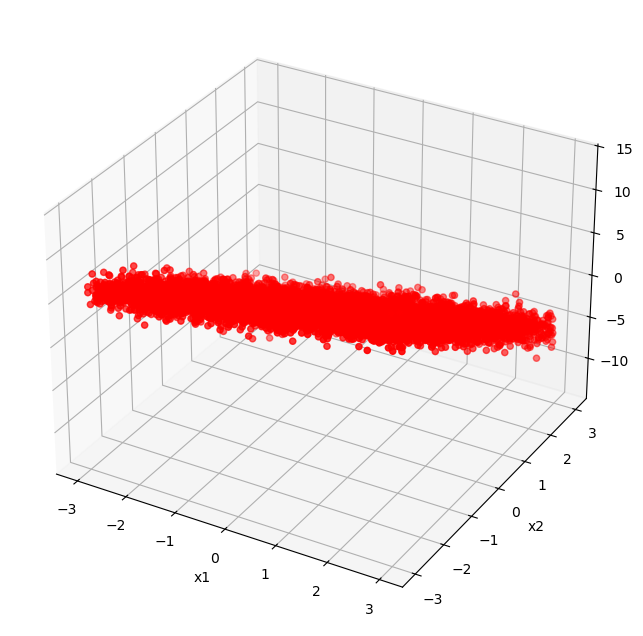

In [153]:
n = 10000
beta = np.array([1.0, -3.])

data = pd.DataFrame({
    'x1': np.random.uniform(-3, 3, n),
    'x2': np.random.uniform(-3, 3, n),
})
data['y'] = beta[0] * data['x1'] +  beta[1] * data['x2'] + np.random.normal(0, 1, data.shape[0])
df = data

# plot the data in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['x1'], df['x2'], df['y'], c='r', marker='o')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
plt.show()

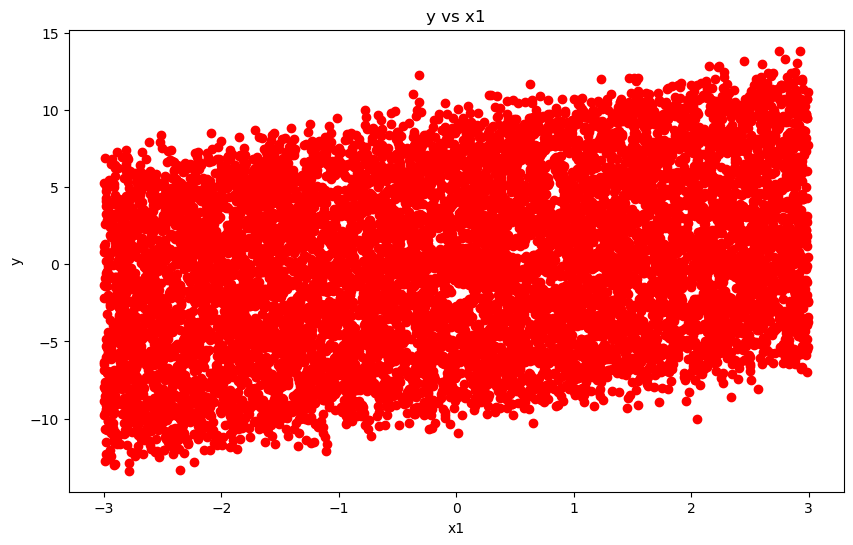

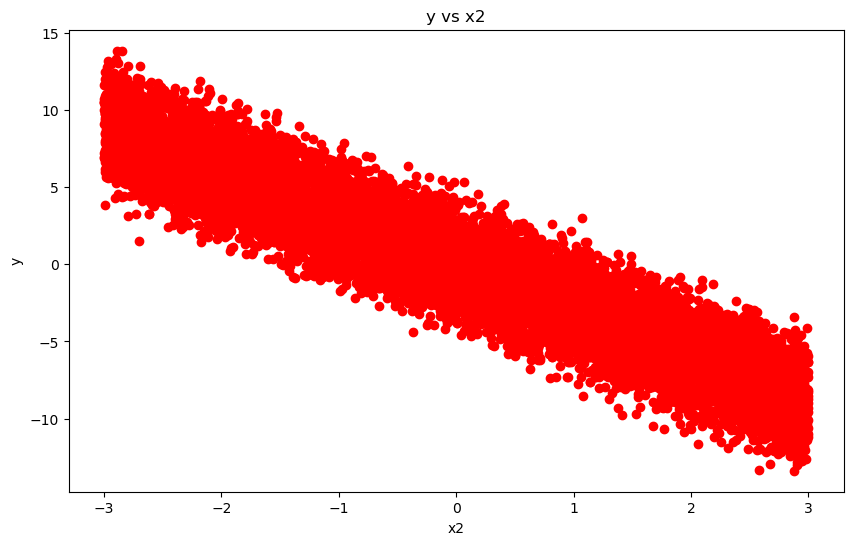

In [3]:
# plot y against x1
plt.figure(figsize=(10, 6))
plt.scatter(df['x1'], df['y'], c='r', marker='o')
plt.xlabel('x1')
plt.ylabel('y')
plt.title('y vs x1')
plt.show()
# plot y against x2
plt.figure(figsize=(10, 6))
plt.scatter(df['x2'], df['y'], c='r', marker='o')
plt.xlabel('x2')
plt.ylabel('y')
plt.title('y vs x2')
plt.show()


In [5]:
from torch import nn
from pyro.nn import PyroModule

assert issubclass(PyroModule[nn.Linear], nn.Linear)
assert issubclass(PyroModule[nn.Linear], PyroModule)

In [9]:
# Dataset: Add a feature to capture the interaction between "cont_africa" and "rugged"
data = torch.tensor(df.values,
                        dtype=torch.float)
x_data, y_data = data[:, :-1], data[:, -1]

# Regression model
linear_reg_model = PyroModule[nn.Linear](2, 1)

# Define loss and optimize
loss_fn = torch.nn.MSELoss(reduction='sum')
optim = torch.optim.Adam(linear_reg_model.parameters(), lr=0.00001)
num_iterations = 200000
losses = []

def train():
    # run the model forward on the data
    y_pred = linear_reg_model(x_data).squeeze(-1)
    # calculate the mse loss
    loss = loss_fn(y_pred, y_data)
    # initialize gradients to zero
    optim.zero_grad()
    # backpropagate
    loss.backward()
    # take a gradient step
    optim.step()
    return loss

for j in range(num_iterations):
    loss = train()
    losses.append(loss.item())
    if (j + 1) % 50 == 0:
        print("[iteration %04d] loss: %.4f" % (j + 1, loss.item()))


# Inspect learned parameters
print("Learned parameters:")
for name, param in linear_reg_model.named_parameters():
    print(name, param.data.numpy())

[iteration 0050] loss: 188833.7969
[iteration 0100] loss: 188739.2656
[iteration 0150] loss: 188644.7812
[iteration 0200] loss: 188550.3438
[iteration 0250] loss: 188455.9219
[iteration 0300] loss: 188361.5312
[iteration 0350] loss: 188267.2188
[iteration 0400] loss: 188172.9219
[iteration 0450] loss: 188078.6562
[iteration 0500] loss: 187984.4844
[iteration 0550] loss: 187890.3438
[iteration 0600] loss: 187796.2500
[iteration 0650] loss: 187702.1875
[iteration 0700] loss: 187608.1875
[iteration 0750] loss: 187514.2031
[iteration 0800] loss: 187420.2656
[iteration 0850] loss: 187326.3281
[iteration 0900] loss: 187232.4688
[iteration 0950] loss: 187138.9844
[iteration 1000] loss: 187045.6250
[iteration 1050] loss: 186952.3438
[iteration 1100] loss: 186859.0781
[iteration 1150] loss: 186765.8594
[iteration 1200] loss: 186672.6875
[iteration 1250] loss: 186579.5469
[iteration 1300] loss: 186486.4375
[iteration 1350] loss: 186393.3750
[iteration 1400] loss: 186300.3281
[iteration 1450] los

KeyboardInterrupt: 

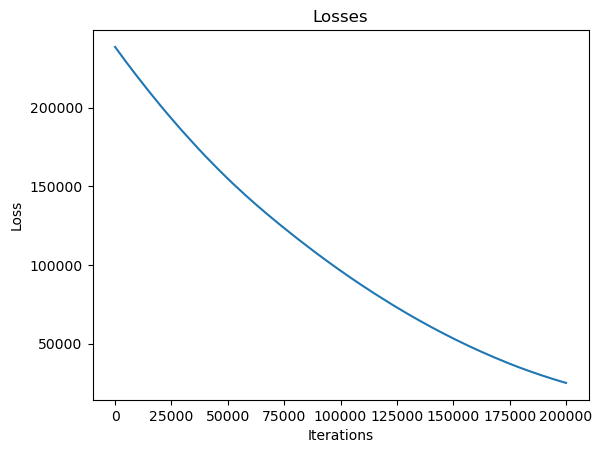

In [ ]:
# plot losses
plt.plot(losses)
plt.title("Losses")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

/tmp/ipykernel_8842/3165438754.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x="x1", y="y", palette="viridis", size=100)


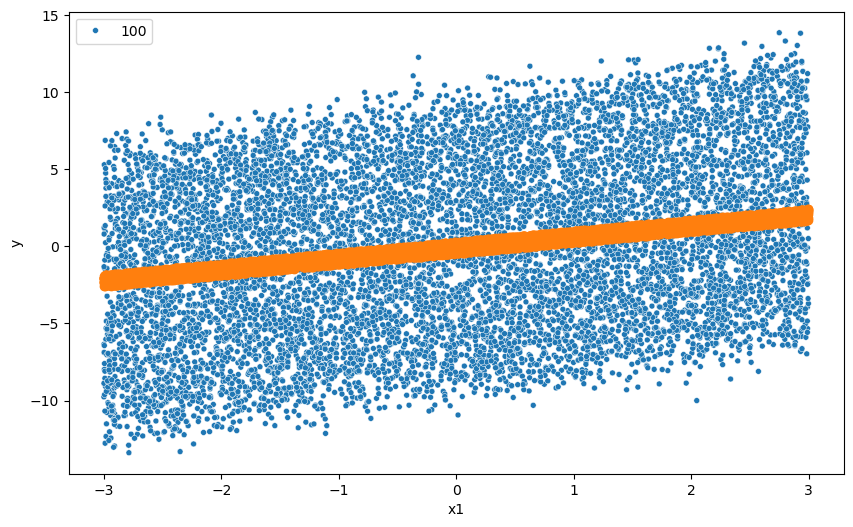

In [33]:
fit = df.copy()
fit["mean"] = linear_reg_model(x_data).detach().cpu().numpy()

# Plot z against x
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="x1", y="y", palette="viridis", size=100)
plt.scatter(fit["x1"], fit["mean"])

plt.show()

In [10]:
from pyro.nn import PyroSample


class BayesianRegression(PyroModule):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = PyroModule[nn.Linear](in_features, out_features)
        self.linear.weight = PyroSample(dist.Normal(0., 1.).expand([out_features, in_features]).to_event(2))
        self.linear.bias = PyroSample(dist.Normal(0., 10.).expand([out_features]).to_event(1))

    def forward(self, x, y=None):
        sigma = pyro.sample("sigma", dist.Uniform(0., 10.))
        mean = self.linear(x).squeeze(-1)
        with pyro.plate("data", x.shape[0]):
            obs = pyro.sample("obs", dist.Normal(mean, sigma), obs=y)

In [11]:
data = torch.tensor(df.values,
                        dtype=torch.float)
x_data, y_data = data[:, :-1], data[:, -1]

In [141]:
from pyro.infer.autoguide import AutoMultivariateNormal

model = BayesianRegression(2, 1)
guide = AutoMultivariateNormal(model)

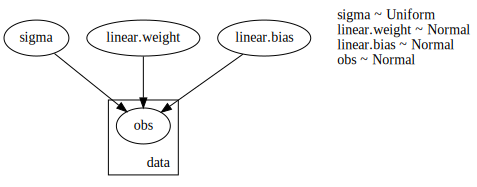

In [142]:
pyro.render_model(model, model_args=(x_data,), render_distributions=True, render_params=True)

In [143]:
from pyro.infer import SVI, Trace_ELBO


adam = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model, guide, adam, loss=Trace_ELBO())

In [144]:
num_iterations = 7500
losses = []

pyro.clear_param_store()
for j in range(num_iterations):
    # calculate the loss and take a gradient step
    loss = svi.step(x_data, y_data)
    losses.append(loss / len(data))
    if j % 100 == 0:
        print("[iteration %04d] loss: %.4f" % (j + 1, loss / len(data)))

[iteration 0001] loss: 4.2717
[iteration 0101] loss: 3.7312
[iteration 0201] loss: 3.5523
[iteration 0301] loss: 3.4631
[iteration 0401] loss: 3.3391
[iteration 0501] loss: 3.2141
[iteration 0601] loss: 3.1207
[iteration 0701] loss: 3.1453
[iteration 0801] loss: 3.0159
[iteration 0901] loss: 3.0607
[iteration 1001] loss: 3.0276
[iteration 1101] loss: 2.9094
[iteration 1201] loss: 2.9012
[iteration 1301] loss: 2.9033
[iteration 1401] loss: 2.9106
[iteration 1501] loss: 2.8464
[iteration 1601] loss: 2.8032
[iteration 1701] loss: 2.7583
[iteration 1801] loss: 2.6666
[iteration 1901] loss: 2.7520
[iteration 2001] loss: 2.6309
[iteration 2101] loss: 2.6854
[iteration 2201] loss: 2.5962
[iteration 2301] loss: 2.4710
[iteration 2401] loss: 2.4926
[iteration 2501] loss: 2.4535
[iteration 2601] loss: 2.3395
[iteration 2701] loss: 2.2764
[iteration 2801] loss: 2.2404
[iteration 2901] loss: 2.0357
[iteration 3001] loss: 2.1254
[iteration 3101] loss: 1.9154
[iteration 3201] loss: 1.9627
[iteration

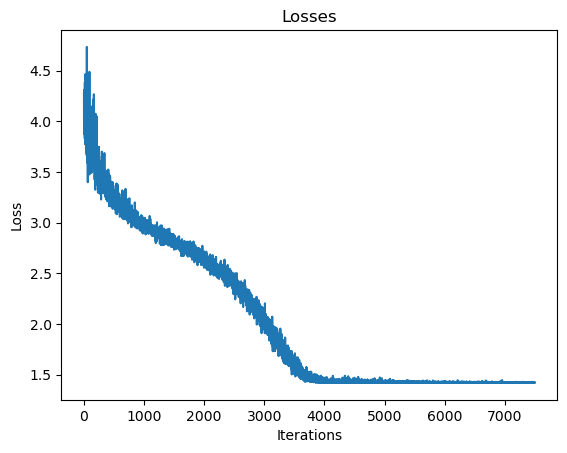

In [145]:
# plot losses
plt.plot(losses)
plt.title("Losses")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [146]:
sample = guide(x_data)
print(sample)

{'sigma': tensor(0.9956, grad_fn=<ExpandBackward0>), 'linear.weight': tensor([[ 0.9902, -2.9748]], grad_fn=<ExpandBackward0>), 'linear.bias': tensor([-0.0060], grad_fn=<ExpandBackward0>)}


In [147]:
guide.requires_grad_(False)

for name, value in pyro.get_param_store().items():
    print(name, pyro.param(name))

AutoMultivariateNormal.loc Parameter containing:
tensor([-2.1965e+00,  1.0121e+00, -2.9975e+00,  1.1796e-03])
AutoMultivariateNormal.scale tensor([0.0311, 0.0127, 0.0263, 0.0193])
AutoMultivariateNormal.scale_tril tensor([[ 1.0000,  0.0000,  0.0000,  0.0000],
        [-0.0147,  1.0000,  0.0000,  0.0000],
        [ 0.1072, -0.0323,  1.0000,  0.0000],
        [-0.0203,  0.0185, -0.0439,  1.0000]])


In [148]:
print(guide.quantiles([0.25, 0.5, 0.75]))


{'sigma': tensor([0.9819, 1.0006, 1.0197]), 'linear.weight': tensor([[[ 1.0036, -3.0153]],

        [[ 1.0121, -2.9975]],

        [[ 1.0207, -2.9796]]]), 'linear.bias': tensor([[-0.0119],
        [ 0.0012],
        [ 0.0142]])}


In [161]:
from pyro.infer import Predictive

n_test = 1000  # number of test samples you want
# Create new test inputs, or use a subset of your data
# Fit a Gaussian to your observed X
mean = x_data.mean(dim=0)
cov = torch.cov(x_data.T)
x_samples = dist.MultivariateNormal(mean, cov).sample((n_test,))

# Use Predictive to sample from the posterior predictive
predictive = Predictive(model, guide=guide, num_samples=1)  # 100 posterior samples
samples = predictive(x_data)

# samples["obs"] contains posterior predictive samples for y
y_post_samples = samples["obs"]  # shape: (num_samples, n_test)
print(y_post_samples.shape)
print(y_post_samples)

torch.Size([1, 10000])
tensor([[-5.2919,  5.7039, -7.9504,  ...,  5.3786, -6.6164,  3.5881]])


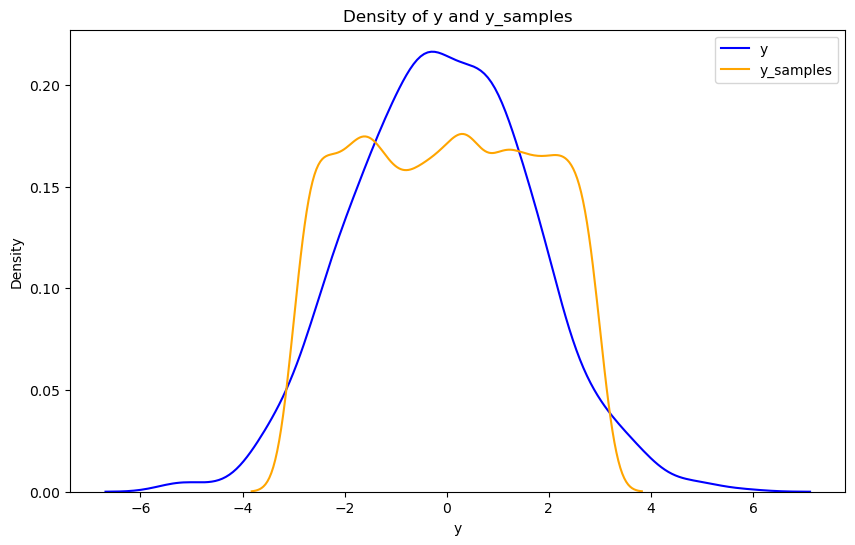

In [166]:
# plot both the density of y and the sampled y
plt.figure(figsize=(10, 6))
sns.kdeplot(data=x_samples[:, 0], label="y", color="blue")
sns.kdeplot(data=x_data[:, 0], label="y_samples", color="orange")
plt.xlabel("y")
plt.ylabel("Density")
plt.title("Density of y and y_samples")
plt.legend()
plt.show()

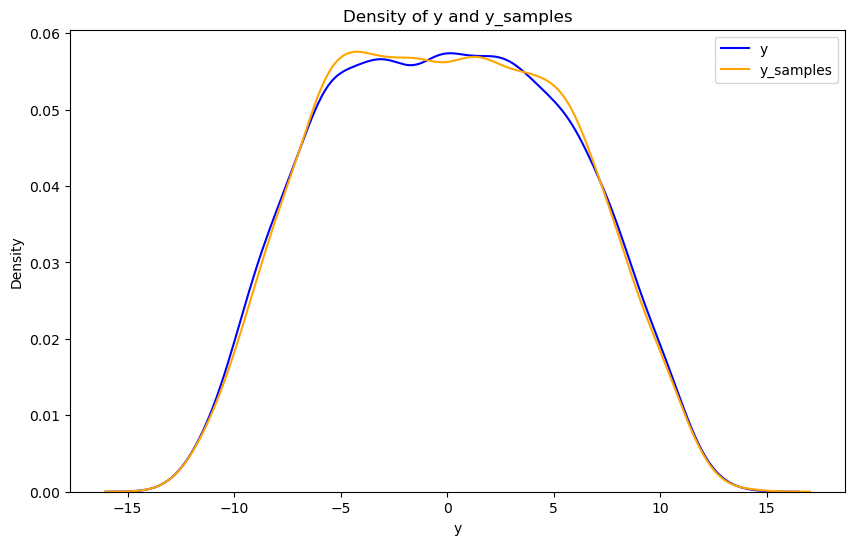

In [162]:
# plot both the density of y and the sampled y
plt.figure(figsize=(10, 6))
sns.kdeplot(data=y_data, label="y", color="blue")
sns.kdeplot(data=y_post_samples.flatten(), label="y_samples", color="orange")
plt.xlabel("y")
plt.ylabel("Density")
plt.title("Density of y and y_samples")
plt.legend()
plt.show()

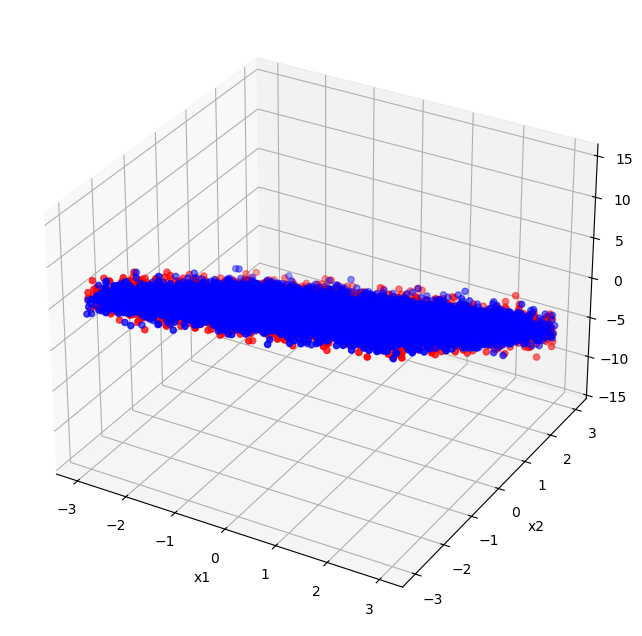

In [165]:
x_samples# plot the data in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['x1'], df['x2'], df['y'], c='r', marker='o')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.scatter(x_data[:, 0], x_data[:, 1], y_post_samples.flatten(), c='b', marker='o')
plt.show()

# interactive plot
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "browser"
import plotly.figure_factory as ff

# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=df['x1'],
    y=df['x2'],
    z=df['y'],
    mode='markers',
    marker=dict(
        size=5,
        color='red',
        opacity=0.8
    )
)])
# Add the predicted points
fig.add_trace(go.Scatter3d(
    x=x_data[:, 0],
    y=x_data[:, 1],
    z=y_post_samples.flatten(),
    mode='markers',
    marker=dict(
        size=5,
        color='blue',
        opacity=0.8
    )
))
# Set the layout
fig.update_layout(
    title='3D Scatter plot of y and predicted y_samples',
    scene=dict(
        xaxis_title='x1',
        yaxis_title='x2',
        zaxis_title='y'
    )
)
# Show the plot
fig.show()
